<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day02_practice1_%EC%B5%9C%EC%86%8C%EC%A0%9C%EA%B3%B1_MSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import matplotlib.pyplot as plt
plt.rcParams["axes.unicode_minus"] = False # 마이너스 부호 깨짐 방지 설정
torch.manual_seed(42)

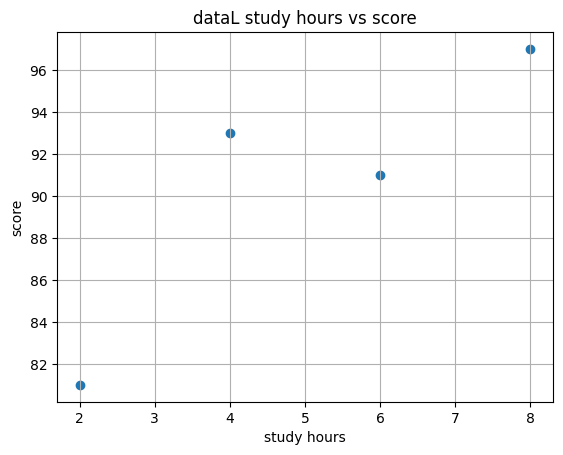

점 4개를 가장 잘 지나는 직선은?


In [ ]:
# 셀 1. 교재 4장의 데이터 - 공부 시간과 성적
x = torch.tensor([2.0, 4.0, 6.0, 8.0]) # 공부 시간
y = torch.tensor([81.0, 93.0, 91.0, 97.0]) # 성적

plt.scatter(x, y)
plt.xlabel("study hours"); plt.ylabel("score"); plt.grid(True)
plt.title("dataL study hours vs score")
plt.savefig("plot1_data.png")
plt.show()
print("점 4개를 가장 잘 지나는 직선은?")

# 우리가 찾는건 y = ax + b의 a(기울기)와 b(절편)
# 가장 훌륭한 예측선 = 점들과의 거리가 가장 작은 직선

In [ ]:
# 셀 2. 최소제곱법

# 최소제곱법 공식:
#   a = Σ(x-x평균)(y-y평균) / Σ(x-x평균)²
#   b = y평균 - (x평균 × a)

x_mean = x.mean()
y_mean = y.mean()

a = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
b = y_mean - (x_mean * a)

print(f"x 평균: {x_mean}, y 평균: {y_mean}")
print(f"기울기 a = {a:.1f}")
print(f"절편 b = {b:.1f}")

# y = 2.3x + 79

x 평균: 5.0, y 평균: 90.5
기울기 a = 2.3
절편 b = 79.0


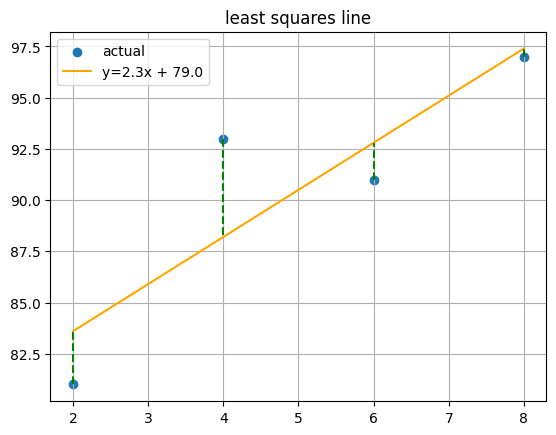

7시간 공부 예측 성적: 95.1점


In [ ]:
# 셀 3. 예측선 그리기 + 예측해 보기
pred = a * x + b

plt.scatter(x, y, label="actual")
plt.plot(x, pred, color="orange", label=f"y={a:.1f}x + {b:.1f}")

# 실제값yi과 예측값pi의 차이(오차)를 세로선으로
for xi, yi, pi in zip(x, y, pred):
  plt.plot([xi, xi], [yi, pi], color="green", ls="--") # Y축 범위: 실제값 yi에서 예측값 pi까지 (두 값 사이를 잇는 선)

plt.legend(); plt.grid(True); plt.title("least squares line")
plt.savefig("plot2_line.png")
plt.show()

print(f"7시간 공부 예측 성적: {a * 7 + b:.1f}점") # y=2.3x + 79

In [ ]:
# 셀 4. 평균 제곱 오차(MSE) - "얼마나 틀렸나"를 숫자 하나로
# MSE = (오차²)의 평균
# 오차 = 실제 - 예측
# 제곱: 부호 없애기
# 평균: 데이터 개수와 무관하게 비교 가능

def mse(y_true, y_pred):
  return((y_true - y_pred) ** 2).mean()

print(f"최적선의 MSE: {mse(y, pred):.2f}")

# 일부러 나쁜 선과 비교
bad_pred = 3.0 * x + 70
print(f"나쁜 선(y=3x+70)의 MSE: {mse(y, bad_pred):.2f}")

최적선의 MSE: 8.30
나쁜 선(y=3x+70)의 MSE: 41.00


In [ ]:
# 최소제곱 공식은 변수가 1개(x)일 때, 변수가 많아지면 경사하강법을 쓴다